<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Logistic_Regression_classwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
## Supervised Learning: Regressions

This lesson introduces __Logistic Regressions__ using __SKLearn__.


### Professor:

<img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Department of Control and Automation Engineering (DECA) <br>
  Institute of Science and Technology of Sorocaba (ICTS) <br>
  São Paulo State University (Unesp) <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

Based on notebooks related to the book:
* Géron, A. "Hands-On Machine Learning with Scikit-Learn and TensorFlow", O’Reilly Media Inc., Sebastopol, CA, EUA.

In [15]:
# -------------------------------------------------------------------
# Logistic Regression on Iris Dataset notebook by Vijay B. Gautam
# https://github.com/GautamVijay/Logistic-Regression-on-IRIS-Dataset
# -------------------------------------------------------------------
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
# Importing the dataset
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/My Drive/Colab Notebooks/iris.csv'

with open(path, "rt") as f:
  dataset = pd.read_csv(path)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
dataset.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Splitting the dataset into the Training set and Test set
X = dataset.iloc[:, [0,1,2, 3]].values
y = dataset.iloc[:, 4].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [6]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [7]:
# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0, solver='lbfgs', multi_class='auto')
classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='auto', random_state=0)

In [8]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

In [9]:
# Predict probabilities
probs_y=classifier.predict_proba(X_test)

Note : Sci-Kit learn is using a default threshold of P>0.5 for binary classifications.

In [10]:
probs_y = np.round(probs_y, 2)

In [12]:
res = "{:<10} | {:<10} | {:<10} | {:<13} | {:<5}".format("y_test", "y_pred", "Setosa(%)", "versicolor(%)", "virginica(%)\n")
res += "-"*65+"\n"
res += "\n".join("{:<10} | {:<10} | {:<10} | {:<13} | {:<10}".format(x, y, a, b, c) for x, y, a, b, c in zip(y_test, y_pred, probs_y[:,0], probs_y[:,1], probs_y[:,2]))
res += "\n"+"-"*65+"\n"
print(res)

y_test     | y_pred     | Setosa(%)  | versicolor(%) | virginica(%)
-----------------------------------------------------------------
virginica  | virginica  | 0.0        | 0.03          | 0.97      
versicolor | versicolor | 0.01       | 0.95          | 0.04      
setosa     | setosa     | 1.0        | 0.0           | 0.0       
virginica  | virginica  | 0.0        | 0.08          | 0.92      
setosa     | setosa     | 0.98       | 0.02          | 0.0       
virginica  | virginica  | 0.0        | 0.01          | 0.99      
setosa     | setosa     | 0.98       | 0.02          | 0.0       
versicolor | versicolor | 0.01       | 0.71          | 0.28      
versicolor | versicolor | 0.0        | 0.73          | 0.27      
versicolor | versicolor | 0.02       | 0.89          | 0.08      
virginica  | virginica  | 0.0        | 0.44          | 0.56      
versicolor | versicolor | 0.02       | 0.76          | 0.22      
versicolor | versicolor | 0.01       | 0.85          | 0.13      
versicol

In [13]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]


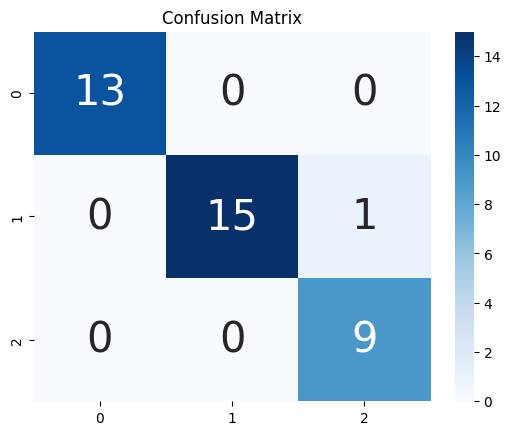

In [14]:
# Plot confusion matrix
import seaborn as sns
import pandas as pd
# confusion matrix sns heatmap
## https://www.kaggle.com/agungor2/various-confusion-matrix-plots
ax = plt.axes()
df_cm = cm
sns.heatmap(df_cm, annot=True, annot_kws={"size": 30}, fmt='d',cmap="Blues", ax = ax )
ax.set_title('Confusion Matrix')
plt.show()

____
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>